#### 2026.07.06
비지도학습

In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

In [2]:
X, y = make_blobs(
    n_samples=300,
    centers=4,
    random_state=42
)

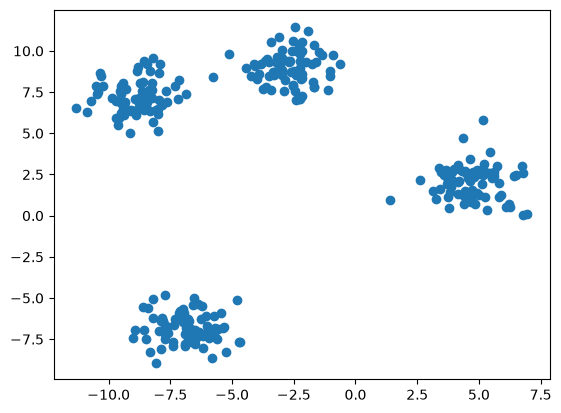

In [3]:
plt.scatter(X[:, 0], X[:, 1])

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',   # 랜덤하게 만들어지는 중심값을 멀리 떨어뜨려서 만드는 옵션
    random_state=42
)

In [5]:
cluster_labels = kmeans.fit_predict(X)
print(cluster_labels)

[3 3 0 1 3 1 2 1 0 2 0 2 0 0 3 0 3 2 0 0 2 0 1 3 0 3 3 1 1 2 0 2 3 2 3 0 3
 1 3 1 2 0 3 1 0 0 3 2 3 2 1 3 1 0 1 2 3 2 2 0 3 2 2 0 1 1 1 1 1 0 1 1 3 2
 0 3 1 1 0 1 0 0 3 0 1 3 3 2 2 2 3 0 3 0 0 3 1 0 3 3 2 2 2 0 0 0 0 0 1 3 2
 0 0 0 0 2 3 1 3 1 1 1 0 3 1 3 3 0 3 1 2 0 0 0 0 2 2 3 0 1 0 2 1 0 2 2 2 2
 1 0 0 3 2 1 0 2 1 3 3 2 0 3 1 3 2 3 1 0 0 0 0 0 1 2 2 1 1 2 2 1 3 0 3 2 2
 3 1 0 2 2 1 1 1 3 2 1 1 2 2 3 0 0 1 2 0 1 1 3 1 0 0 1 1 2 3 1 3 3 0 3 3 1
 3 1 2 2 3 3 2 2 2 3 0 1 2 1 3 2 3 3 3 1 1 2 3 1 1 1 3 1 3 1 3 2 1 3 2 0 3
 0 2 0 3 0 1 2 1 2 2 0 0 1 2 2 3 3 1 0 0 2 2 2 2 1 3 2 1 2 2 1 0 1 2 0 3 0
 2 0 3 3]


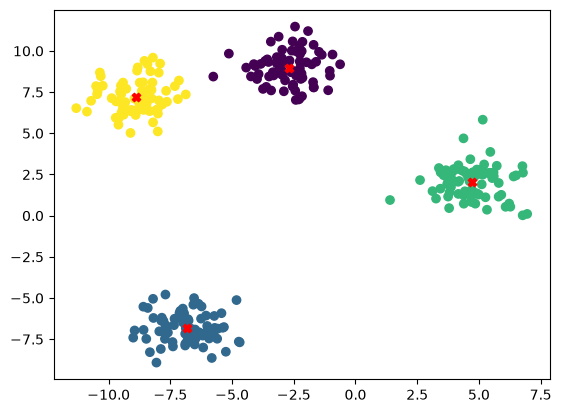

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis')
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c = 'red',
    marker='X'
)

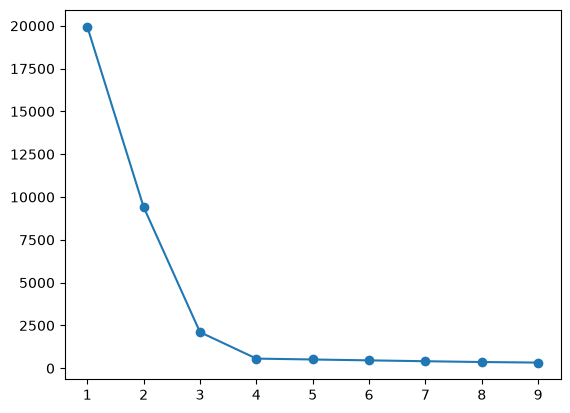

In [7]:
result = []
for k in range(1,10) :
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans_temp.fit_predict(X)
    result.append(kmeans_temp.inertia_)

plt.plot(range(1,10), result, marker='o')

In [8]:
# 실루엣 점수
from sklearn.metrics import silhouette_score, silhouette_samples

In [9]:
sil_score = silhouette_score(X, cluster_labels)
print(sil_score)

0.7915830011443039


In [10]:
sil_values = silhouette_samples(X, cluster_labels)
print(sil_values)

[0.80600451 0.80216071 0.73893458 0.87948243 0.71930267 0.90063471
 0.8710494  0.90827138 0.79909098 0.79917381 0.67810765 0.86416759
 0.66819132 0.67698901 0.81012669 0.77928758 0.75408624 0.72665936
 0.78160132 0.68083316 0.84037847 0.80749222 0.89582869 0.81516562
 0.78945463 0.6456291  0.7639259  0.7951111  0.90158165 0.82779032
 0.73468472 0.8178537  0.73802264 0.84127989 0.68750863 0.75713022
 0.74374922 0.91150739 0.79603318 0.82637541 0.8389285  0.81272915
 0.81488503 0.87235309 0.75172136 0.73802997 0.81210162 0.86328129
 0.80005662 0.81162246 0.90816901 0.68055866 0.8980895  0.74146687
 0.88514061 0.53179664 0.79581203 0.85366183 0.86145934 0.75707197
 0.74493573 0.76455439 0.85817039 0.0634864  0.88575261 0.88640631
 0.9001295  0.88313919 0.8544984  0.73852637 0.87870933 0.84510454
 0.79577041 0.87230205 0.70250671 0.79789834 0.83317117 0.89781966
 0.78855388 0.88348048 0.74987952 0.77679308 0.76667658 0.7801336
 0.8919131  0.72102419 0.67459466 0.80748076 0.81461896 0.78929

In [11]:
import numpy as np

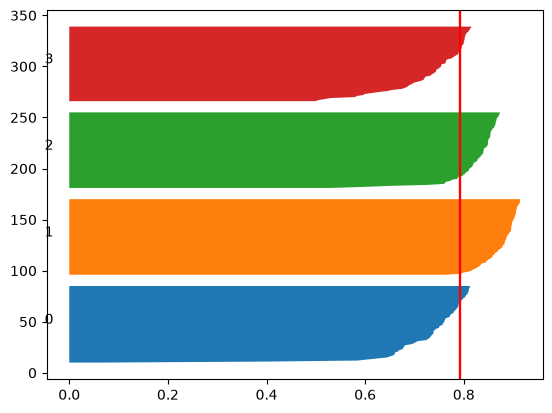

In [12]:
y_lower = 10
for i in range(4): # 각 클러스터에대해 반복
    ith_cluster_silhouette_values = sil_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i  # 클러스터별막대 그리기

    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i)) # 클러스터번호
    y_lower = y_upper + 10 # 다음 클러스터로이동

    plt.axvline(x=sil_score, color='red')

차원축소 : PCA

In [13]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [14]:
iris = load_iris()  # 데이터셋
X = iris.data   # 특성 = 4차원 -> 2차원
y = iris.target # 0, 1, 2

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
# PCA
pca = PCA(n_components=2)   # 2개의 주성분으로 축소
X_pca = pca.fit_transform(X_scaled)

In [17]:
# 주성분이 데이터를 얼마나 잘 설명하는지 지표 확인
print(pca.explained_variance_ratio_)

[0.72962445 0.22850762]


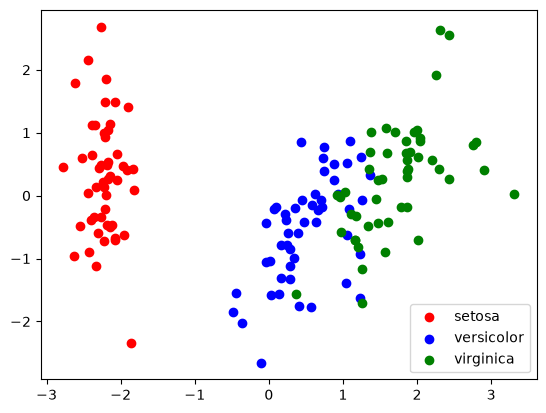

In [18]:
for target, color, label in zip([0,1,2], ['red', 'blue', 'green'], iris.target_names) :
    plt.scatter(
        X_pca[y == target, 0],  # 첫번째 주성분
        X_pca[y == target, 1],  # 두번째 주성분
        color = color, label = label
    )

    plt.legend()

Isolation Forset : 이상치 탐지

In [19]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [20]:
np.random.seed(42)

# 정상데이터 100개, 2차원
normal_traffic = np.random.normal(loc=50, scale=10, size=(100,2))
# print(normal_traffic)

# 이상 데이터 10개, 2차원
ano_traffic = np.random.uniform(low=100, high=150, size=(10,2))
# print(ano_traffic)

# 데이터 병합
traffic_data = np.vstack((normal_traffic, ano_traffic))
# print(traffic_data)

traffic_df = pd.DataFrame(traffic_data, columns=['Request Time', 'Response Time'])

In [21]:
traffic_df

,Request Time,Response Time
0,54.967142,48.617357
1,56.476885,65.230299
2,47.658466,47.658630
3,65.792128,57.674347
4,45.305256,55.425600
...,...,...
105,125.567120,125.075815
106,139.914759,132.498197
107,135.098344,139.789633
108,144.500267,116.899758


In [22]:
# 학습 모델 생성
model = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42
)

In [23]:
traffic_df['Anomaly Score'] = model.fit_predict(traffic_data)

In [24]:
traffic_df

,Request Time,Response Time,Anomaly Score
0,54.967142,48.617357,1
1,56.476885,65.230299,1
2,47.658466,47.658630,1
3,65.792128,57.674347,1
4,45.305256,55.425600,1
...,...,...,...
105,125.567120,125.075815,-1
106,139.914759,132.498197,-1
107,135.098344,139.789633,-1
108,144.500267,116.899758,-1


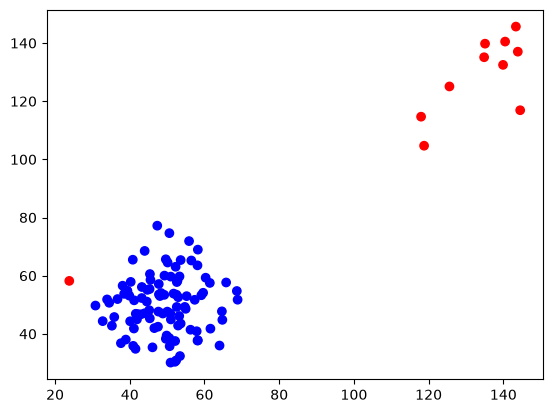

In [25]:
plt.scatter(
    traffic_df['Request Time'],
    traffic_df['Response Time'],
    c=traffic_df['Anomaly Score'].map({1:'blue', -1:'red'})
)

DBSCAN

In [26]:
from sklearn.cluster import DBSCAN

In [27]:
np.random.seed(42)

# 정상데이터 100개, 2차원
normal_traffic = np.random.normal(loc=50, scale=10, size=(100,2))
# print(normal_traffic)

# 이상 데이터 10개, 2차원
ano_traffic = np.random.uniform(low=100, high=150, size=(10,2))
# print(ano_traffic)

# 데이터 병합
traffic_data = np.vstack((normal_traffic, ano_traffic))
# print(traffic_data)

traffic_df = pd.DataFrame(traffic_data, columns=['Request Time', 'Response Time'])

In [28]:
dbscan = DBSCAN(eps=15, min_samples=10)

In [29]:
# 이상치 : -1, 나머지 : 클러스터 ID 
traffic_df['Cluster'] = dbscan.fit_predict(traffic_df)

In [30]:
traffic_df

,Request Time,Response Time,Cluster
0,54.967142,48.617357,0
1,56.476885,65.230299,0
2,47.658466,47.658630,0
3,65.792128,57.674347,0
4,45.305256,55.425600,0
...,...,...,...
105,125.567120,125.075815,-1
106,139.914759,132.498197,-1
107,135.098344,139.789633,-1
108,144.500267,116.899758,-1


In [31]:
traffic_df['Anomaly'] = traffic_df['Cluster'].apply(lambda x : 'Anomaly' if x == -1 else 'Normal')

In [32]:
traffic_df

,Request Time,Response Time,Cluster,Anomaly
0,54.967142,48.617357,0,Normal
1,56.476885,65.230299,0,Normal
2,47.658466,47.658630,0,Normal
3,65.792128,57.674347,0,Normal
4,45.305256,55.425600,0,Normal
...,...,...,...,...
105,125.567120,125.075815,-1,Anomaly
106,139.914759,132.498197,-1,Anomaly
107,135.098344,139.789633,-1,Anomaly
108,144.500267,116.899758,-1,Anomaly


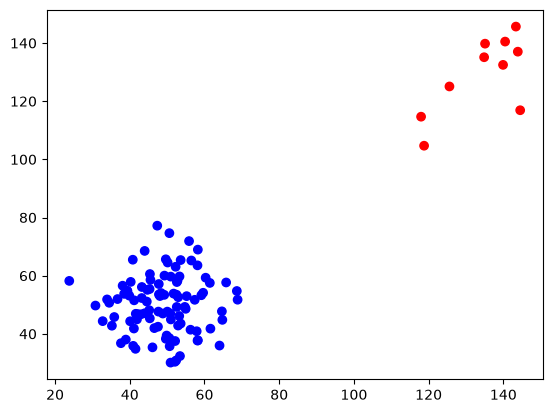

In [33]:
plt.scatter(
    traffic_df['Request Time'],
    traffic_df['Response Time'],
    c=traffic_df['Anomaly'].map({'Normal':'blue', 'Anomaly':'red'})
)